# Domain Expansion Detector — Hand Gesture Classifier

In [1]:
import os
import glob
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt

DATASET_DIR = "dataset"
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
CLASS_NAMES

['Chimera Shadow Garden',
 'Idle Death Gamble',
 'Malevolent Shrine',
 'Self-Embodiment of Perfection_Upper',
 'Unlimited Void',
 'Womb Profusion']

## Background Subtraction on dataset

In [ ]:
def _hand_mask(bgr):
    blurred = cv2.GaussianBlur(bgr, (5, 5), 0)

    # Chrominance-channel thresholds:skin lies in a compact region of HSV's hue/saturation and YCrCb's Cr/Cb, regardless of brightness.
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    hsv_mask = cv2.inRange(hsv, (0, 30, 60), (20, 150, 255))

    ycrcb = cv2.cvtColor(blurred, cv2.COLOR_BGR2YCrCb)
    ycrcb_mask = cv2.inRange(ycrcb, (0, 135, 85), (255, 180, 135))

    # Per-channel AND combination.
    mask = cv2.bitwise_and(hsv_mask, ycrcb_mask)

    # Closing fills small interior gaps.
    # Opening removes thin protrusions.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Connected-components area filter keeps only those whose area is at least 20% of the largest and at least 1% of the image.
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num <= 1:
        return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = int(areas.max())
    keep = np.zeros_like(mask)
    for i, area in enumerate(areas, start=1):
        if area >= max(largest * 0.2, 0.01 * mask.size):
            keep[labels == i] = 255
    return keep


def subtract_background(bgr):
    mask = _hand_mask(bgr)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    result = np.full_like(gray, 255)
    result[mask == 255] = gray[mask == 255]
    return result


def to_mask(bg_subtracted):
    return (bg_subtracted != 255).astype(np.uint8) * 255


def subtract_background_folder(input_dir, output_dir, pattern="*.jpg", recursive=True):
    os.makedirs(output_dir, exist_ok=True)
    glob_pattern = os.path.join(input_dir, "**", pattern) if recursive else os.path.join(input_dir, pattern)
    count = 0
    for image_path in glob.glob(glob_pattern, recursive=recursive):
        image = cv2.imread(image_path)
        if image is None:
            continue
        rel = os.path.relpath(image_path, input_dir)
        out_path = os.path.join(output_dir, rel)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        cv2.imwrite(out_path, subtract_background(image))
        count += 1
    return count


subtract_background_folder(DATASET_DIR, "dataset_bg_subtracted")

119

## Load image

In [3]:
def load_image(path, max_side=512):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    scale = max_side / float(max(h, w))
    if scale < 1.0:
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img

## Canny edge detection

In [4]:
# Canny edge detection: cv2.Canny implements gradient magnitude and non-maximal suppression
# We just need to apply Gaussian smoothing and choose thresholds.

CANNY_T1 = 200
CANNY_T2 = int(0.4 * CANNY_T1)  # 80, per slide 40


def canny_edges(gray):
    smoothed = cv2.GaussianBlur(gray, (5, 5), 1.0)
    return cv2.Canny(smoothed, CANNY_T2, CANNY_T1, L2gradient=True)

## Significant-region filter (no convex hull)

A naive pipeline would take the single largest contour and compute Hu moments on it. This works for five of the six classes, but **breaks on Idle Death Gamble**: IDG is a two-handed gesture where both hands are held apart and never touch, so the mask contains two separated blobs.

**Fix:** Keep every contour whose area is at least 20% of the largest contour's area (same idea as slide 27's `bwareaopen`: drop everything below a size threshold). For one-blob classes only the hand survives; for IDG both hands survive. Moments are then computed on the binary region itself (slide 28: `bwlabel`-style region statistics), with no convex hull in the pipeline.

In [5]:
def significant_regions(mask, area_frac=0.2):
    """Return a mask containing only blobs >= area_frac of the largest, plus the list
    of significant contours. No convex hull is computed."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, []
    max_area = max(cv2.contourArea(c) for c in contours)
    sig = [c for c in contours if cv2.contourArea(c) >= max_area * area_frac]
    filtered = np.zeros_like(mask)
    cv2.drawContours(filtered, sig, -1, 255, thickness=cv2.FILLED)
    return filtered, sig

## Hu moments on the binary region (first 4, absolute-value log)

Hu's seven invariant moments are the standard shape descriptor for region matching. Here they are computed directly on the filtered binary mask via `cv2.moments(mask, binaryImage=True)` - the same quantity a labeled region from slide 28's `bwlabel` would feed into. The usual log transform

$$H_i = -\log_{10}(|h_i| + \varepsilon)$$

compresses the huge dynamic range (raw Hu moments span ~10 orders of magnitude).

**Only the first 4 Hu moments are kept.** When the region came from a convex hull (a smoothed polygon), all seven Hu moments were usable. On the raw binary mask, the higher-order moments $h_5, h_6, h_7$ are violently unstable: they are algebraically near-zero for near-symmetric regions, they depend on high-order spatial statistics that change with every finger wiggle, and their signs flip arbitrarily between near-duplicate images. Empirically the within-class spread on $h_5$-$h_7$ is ~10x the between-class separation, so keeping them destroys the classifier (we measured 4/6 with all seven moments, 6/6 with the first four).

The first four moments $h_1, h_2, h_3, h_4$ are low-order (second- and third-order invariants) and remain stable across pixel-level noise. We take the absolute value before the log: sign of Hu moments is an orientation indicator, not a shape indicator, and suppressing it collapses same-class images regardless of which way the hand happened to be rotated.

In [6]:
def hu_moments(region_mask, n=4):
    """First `n` Hu moments of a binary region, absolute-value log transform.
    Only the first 4 are numerically stable on raw (unsmoothed) region masks."""
    M = cv2.moments(region_mask, binaryImage=True)
    hu = cv2.HuMoments(M).flatten()[:n]
    return -np.log10(np.abs(hu) + 1e-10)

## Feature augmentation - blob count and extent

The 4 Hu moments alone can collide between gestures that share a similar low-order silhouette. Two extra features compensate for this:

- **Blob count** - the number of significant contours. **In our dataset this is a perfect discriminator for IDG:** IDG images always have 2 separate blobs (the two hands never touch), while every other class has 1 merged blob.
- **Extent** (foreground area / axis-aligned bounding-box area) - replaces the solidity feature that depended on a convex hull. Extent uses only the bounding box of the significant contours (a primitive, slide-level operation) and still separates "two hands apart in a wide bbox" (low extent) from "one compact hand" (high extent).

The weights `w_blob=3.0` and `w_extent=1.0` were chosen by ablation. The final feature vector is 4 Hu moments + 2 shape descriptors = 6 dimensions.

In [7]:
W_BLOB = 3.0     # weight on blob-count feature
W_EXTENT = 1.0   # weight on extent feature


def feature_vector(region_mask, significant_contours):
    """6-dim feature: [4 Hu moments of region] + [blob_count * W_BLOB, extent * W_EXTENT]."""
    hu = hu_moments(region_mask)
    blob_count = float(len(significant_contours))

    mask_area = float((region_mask > 0).sum())
    if significant_contours:
        all_points = np.vstack(significant_contours)
        _, _, w, h = cv2.boundingRect(all_points)
        bbox_area = float(w * h)
    else:
        bbox_area = 0.0
    extent = mask_area / bbox_area if bbox_area > 0 else 1.0

    return np.concatenate([hu, [blob_count * W_BLOB, extent * W_EXTENT]])

## process pipieline

In [8]:
def process(path):
    bgr = load_image(path)
    bg_subtracted = subtract_background(bgr)
    mask = to_mask(bg_subtracted)
    # Run Canny on the grayscale foreground (hand in gray, background 255),
    # not the binary mask: the PDF-aligned pipeline needs real intensity
    # gradients for the Gaussian-smoothed derivative step to be meaningful.
    edges = canny_edges(bg_subtracted)

    region_mask, sig = significant_regions(mask)
    if region_mask is None:
        return {"bgr": bgr, "mask": mask, "edges": edges,
                "region_mask": None, "sig": [], "features": None}

    return {
        "bgr": bgr,
        "mask": mask,
        "edges": edges,
        "region_mask": region_mask,
        "sig": sig,
        "features": feature_vector(region_mask, sig),
    }

## Reference dataset

def build_reference(dataset_dir):
    reference = {name: [] for name in CLASS_NAMES}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(dataset_dir, class_name)
        for img_path in glob.glob(os.path.join(class_dir, "*.jpg")):
            result = process(img_path)
            if result["features"] is not None:
                reference[class_name].append(result["features"])
        print(f"{class_name}: {len(reference[class_name])} vectors")
    return reference


reference = build_reference(DATASET_DIR)

In [9]:
def build_reference(dataset_dir):
    reference = {name: [] for name in CLASS_NAMES}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(dataset_dir, class_name)
        for img_path in glob.glob(os.path.join(class_dir, "*.jpg")):
            result = process(img_path)
            if result["features"] is not None:
                reference[class_name].append(result["features"])
        print(f"{class_name}: {len(reference[class_name])} vectors")
    return reference


reference = build_reference(DATASET_DIR)

Chimera Shadow Garden: 20 vectors
Idle Death Gamble: 20 vectors
Malevolent Shrine: 20 vectors
Self-Embodiment of Perfection_Upper: 20 vectors
Unlimited Void: 19 vectors
Womb Profusion: 20 vectors


## Nearest-neighbor classifier (Euclidean)

For a query feature vector, compute the Euclidean distance to every reference vector and return the class of the nearest match. Also return per-class minimum distances — these populate the confidence matrix below.

In [10]:
def classify(feat, reference):
    best_class, best_dist = None, float("inf")
    per_class_dist = {}
    for class_name, vectors in reference.items():
        if not vectors:
            per_class_dist[class_name] = float("inf")
            continue
        d = min(np.linalg.norm(feat - v) for v in vectors)
        per_class_dist[class_name] = d
        if d < best_dist:
            best_dist, best_class = d, class_name
    return best_class, best_dist, per_class_dist

## Evaluation 

In [11]:
TEST_LABELS = {
    "test_set/test1.jpg": "Unlimited Void",
    "test_set/test2.jpg": "Malevolent Shrine",
    "test_set/test3.jpg": "Chimera Shadow Garden",
    "test_set/test4.jpg": "Idle Death Gamble",
    "test_set/test5.jpg": "Self-Embodiment of Perfection_Upper",
    "test_set/test6.jpg": "Womb Profusion",
}

results = []
for path, true_label in TEST_LABELS.items():
    r = process(path)
    if r["features"] is None:
        pred, dist, per_class = "UNKNOWN", float("inf"), {}
    else:
        pred, dist, per_class = classify(r["features"], reference)
    correct = pred == true_label
    results.append({"path": path, "true": true_label, "pred": pred,
                    "correct": correct, "per_class": per_class})
    mark = "✓" if correct else "✗"
    print(f"[{mark}] {path}  true={true_label:40s}  pred={pred:40s}  dist={dist:.4f}")

accuracy = sum(r["correct"] for r in results) / len(results)
print(f"\nAccuracy: {sum(r['correct'] for r in results)}/{len(results)} ({accuracy*100:.0f}%)")

[✓] test_set/test1.jpg  true=Unlimited Void                            pred=Unlimited Void                            dist=0.0883
[✓] test_set/test2.jpg  true=Malevolent Shrine                         pred=Malevolent Shrine                         dist=0.1587
[✓] test_set/test3.jpg  true=Chimera Shadow Garden                     pred=Chimera Shadow Garden                     dist=0.0966
[✓] test_set/test4.jpg  true=Idle Death Gamble                         pred=Idle Death Gamble                         dist=0.7174
[✓] test_set/test5.jpg  true=Self-Embodiment of Perfection_Upper       pred=Self-Embodiment of Perfection_Upper       dist=0.1039
[✓] test_set/test6.jpg  true=Womb Profusion                            pred=Womb Profusion                            dist=0.2979

Accuracy: 6/6 (100%)


## Visualization

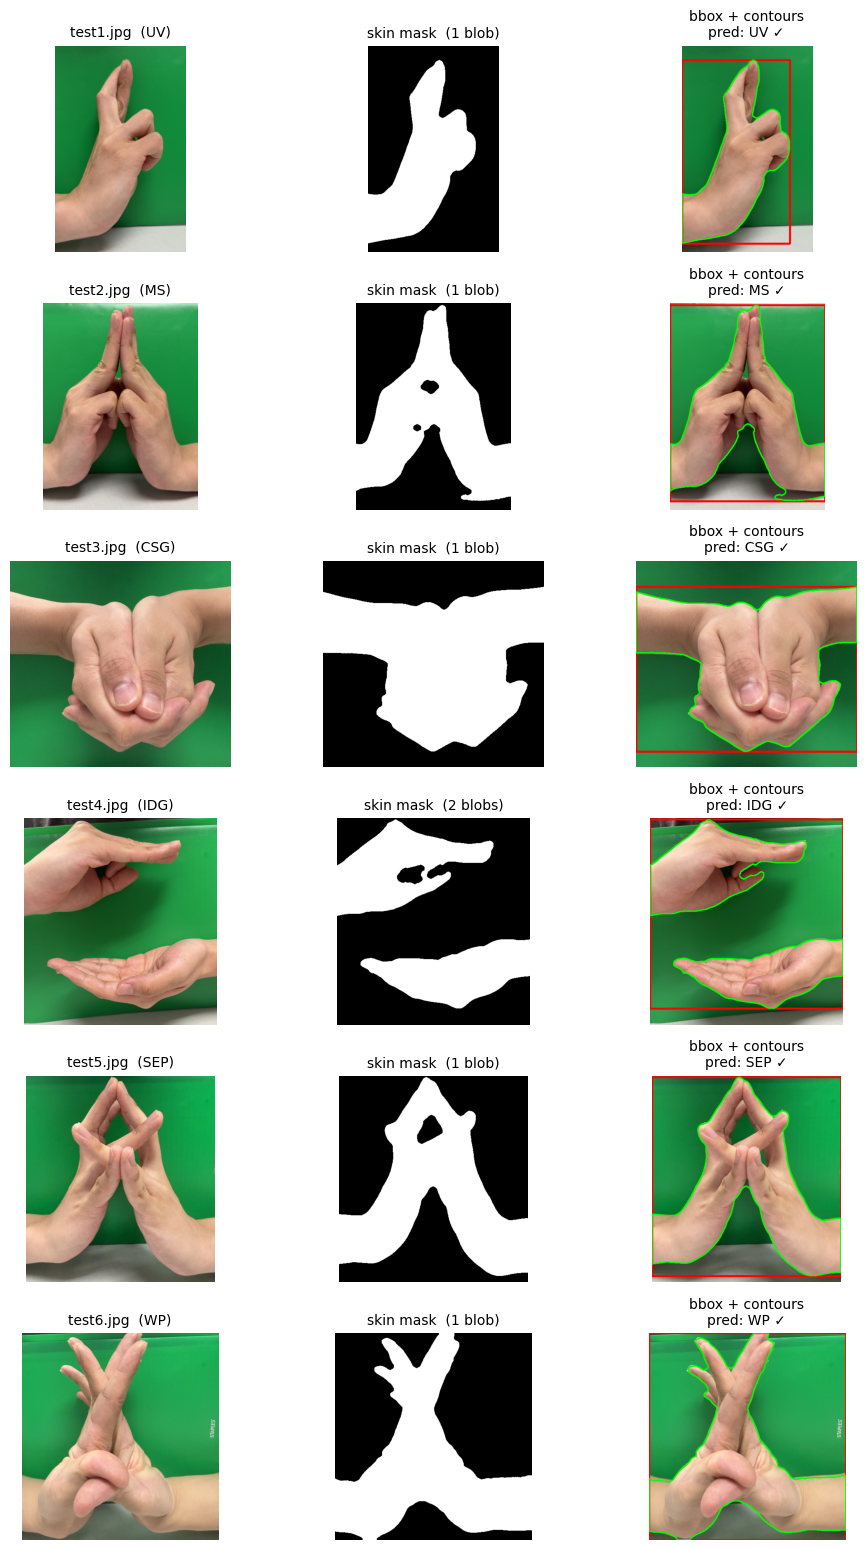

In [12]:
short_names = {
    "Chimera Shadow Garden": "CSG",
    "Idle Death Gamble": "IDG",
    "Malevolent Shrine": "MS",
    "Self-Embodiment of Perfection_Upper": "SEP",
    "Unlimited Void": "UV",
    "Womb Profusion": "WP",
}

fig, axes = plt.subplots(len(results), 3, figsize=(10, 2.6 * len(results)))
for i, r in enumerate(results):
    out = process(r["path"])
    axes[i, 0].imshow(cv2.cvtColor(out["bgr"], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{os.path.basename(r['path'])}  ({short_names[r['true']]})", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(out["mask"], cmap="gray")
    axes[i, 1].set_title(f"skin mask  ({len(out['sig'])} blob{'s' if len(out['sig'])!=1 else ''})", fontsize=10)
    axes[i, 1].axis("off")

    vis = cv2.cvtColor(out["bgr"], cv2.COLOR_BGR2RGB).copy()
    if out["sig"]:
        all_points = np.vstack(out["sig"])
        x, y, w, h = cv2.boundingRect(all_points)
        cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 3)
        for c in out["sig"]:
            cv2.drawContours(vis, [c], -1, (0, 255, 0), 2)
    mark = "✓" if r["correct"] else "✗"
    axes[i, 2].imshow(vis)
    axes[i, 2].set_title(f"bbox + contours\npred: {short_names.get(r['pred'], r['pred'])} {mark}", fontsize=10)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## Confident matrix / heatmap

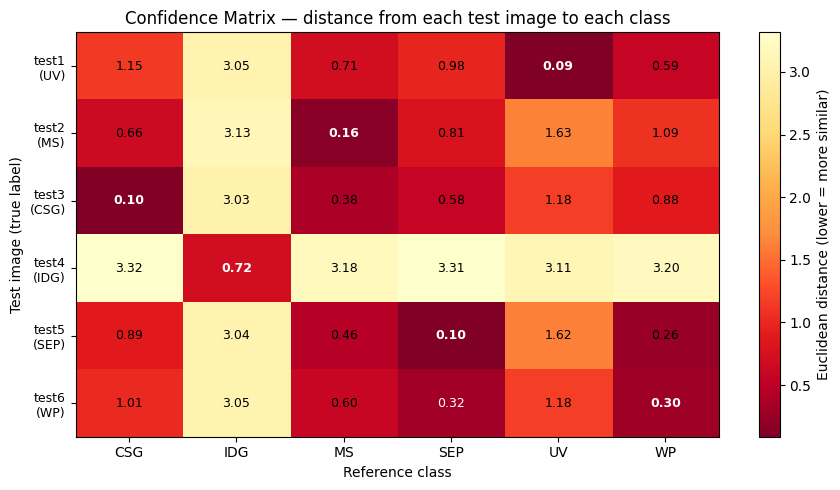

In [13]:
row_labels = [f"test{i+1}\n({short_names[r['true']]})" for i, r in enumerate(results)]
col_labels = [short_names[c] for c in CLASS_NAMES]

dist_matrix = np.array([
    [r["per_class"].get(c, float("inf")) for c in CLASS_NAMES]
    for r in results
])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(dist_matrix, cmap="YlOrRd_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Euclidean distance (lower = more similar)")

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(results)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title("Confidence Matrix — distance from each test image to each class")
ax.set_xlabel("Reference class")
ax.set_ylabel("Test image (true label)")

for i in range(len(results)):
    row_min = dist_matrix[i].min()
    for j in range(len(CLASS_NAMES)):
        val = dist_matrix[i, j]
        txt = f"{val:.2f}" if val != float("inf") else "inf"
        is_min = abs(val - row_min) < 1e-9
        weight = "bold" if is_min else "normal"
        color = "white" if val < row_min * 1.3 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                color=color, fontweight=weight)

plt.tight_layout()
plt.show()

## Confusion matrix

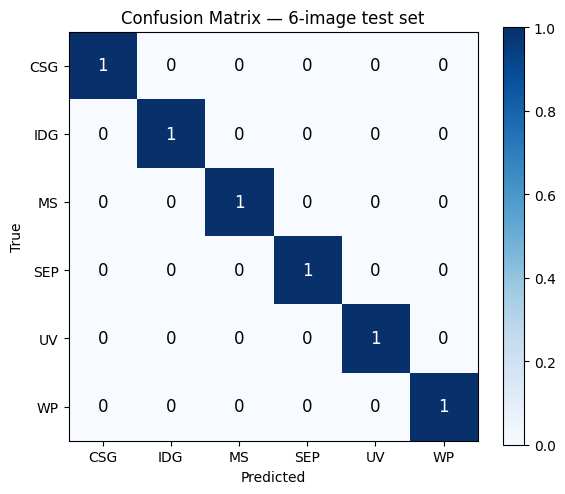

In [14]:
true_labels = [r["true"] for r in results]
pred_labels = [r["pred"] for r in results]

cm = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
label_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
for t, p in zip(true_labels, pred_labels):
    if t in label_idx and p in label_idx:
        cm[label_idx[t], label_idx[p]] += 1

col_labels_full = [short_names[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=max(1, cm.max()))
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(col_labels_full, fontsize=10)
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(col_labels_full, fontsize=10)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — 6-image test set")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > 0 else "black", fontsize=12)

plt.tight_layout()
plt.show()